In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
model = PDEInspiredModel(ts_model=LSTMPrediction,model_channels=4)
model = model.to(device)
model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

tensor([[0.3954, 0.2528, 0.3518]], grad_fn=<SoftmaxBackward0>)

In [10]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)

history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

parameter count: 247

saving model

4.919530338653999e-10
epoch 0, loss=1.615547776222229, val. loss=1.4544575214385986, val. acc.=0.4373795688152313, time: 178ms

saving model

0.0
epoch 1, loss=1.554487705230713, val. loss=1.449473261833191, val. acc.=0.4566473960876465, time: 160ms
2.1579153741679846e-10
epoch 2, loss=1.5579248070716858, val. loss=1.450230360031128, val. acc.=0.1059730276465416, time: 152ms
0.0
epoch 3, loss=1.542438268661499, val. loss=1.4647806882858276, val. acc.=0.1059730276465416, time: 150ms
1.2566947482639534e-10
epoch 4, loss=1.5295574069023132, val. loss=1.4844838380813599, val. acc.=0.1059730276465416, time: 145ms
1.4860112584891283e-09
epoch 5, loss=1.5527958869934082, val. loss=1.4872009754180908, val. acc.=0.1059730276465416, time: 151ms
6.742928437830642e-10
epoch 6, loss=1.536081612110138, val. loss=1.470494031906128, val. acc.=0.1059730276465416, time: 147ms
5.224987525975777e-10
epoch 7, loss=1.5302065014839172, val. loss=1.4581655263900757, val. ac

2.4944962206063792e-05
epoch 65, loss=0.5286991894245148, val. loss=0.4486013650894165, val. acc.=0.8959537744522095, time: 140ms
8.215705747716129e-06
epoch 66, loss=0.4981650561094284, val. loss=0.5020877718925476, val. acc.=0.8227360248565674, time: 138ms
8.016379752007197e-05
epoch 67, loss=0.5246255695819855, val. loss=0.44637101888656616, val. acc.=0.8940269947052002, time: 143ms
5.2699284424306825e-05
epoch 68, loss=0.5152790397405624, val. loss=0.4828517436981201, val. acc.=0.8362234830856323, time: 137ms
6.473039502452593e-05
epoch 69, loss=0.47956226766109467, val. loss=0.44441425800323486, val. acc.=0.8940269947052002, time: 142ms
6.814551306888461e-05
epoch 70, loss=0.5062887519598007, val. loss=0.4677075445652008, val. acc.=0.849711000919342, time: 143ms
3.291874600108713e-05
epoch 71, loss=0.48703667521476746, val. loss=0.44096484780311584, val. acc.=0.899807333946228, time: 141ms
3.3813772461144254e-05
epoch 72, loss=0.5047257244586945, val. loss=0.45602068305015564, val

0.0
epoch 129, loss=0.4319348633289337, val. loss=0.4312804341316223, val. acc.=0.8921002149581909, time: 138ms
1.1992132613158901e-05
epoch 130, loss=0.45843449234962463, val. loss=0.4382129907608032, val. acc.=0.8824662566184998, time: 137ms
4.284915848984383e-05
epoch 131, loss=0.4700659364461899, val. loss=0.4306159019470215, val. acc.=0.8921002149581909, time: 144ms
2.363703606533818e-05
epoch 132, loss=0.4694228619337082, val. loss=0.42561075091362, val. acc.=0.8978805541992188, time: 139ms
4.613385499396827e-05
epoch 133, loss=0.4690435826778412, val. loss=0.4439546763896942, val. acc.=0.8709055781364441, time: 142ms
0.0
epoch 134, loss=0.4430224150419235, val. loss=0.450585275888443, val. acc.=0.8516377806663513, time: 136ms
0.0008215212210416212
epoch 135, loss=0.46682409942150116, val. loss=0.42317479848861694, val. acc.=0.8978805541992188, time: 140ms
2.607029273349326e-05
epoch 136, loss=0.4438614249229431, val. loss=0.4589899778366089, val. acc.=0.8439306616783142, time: 1

1.559620136504236e-05
epoch 193, loss=0.4668719619512558, val. loss=0.41967350244522095, val. acc.=0.899807333946228, time: 139ms
7.689857852710702e-06
epoch 194, loss=0.43694594502449036, val. loss=0.4280972480773926, val. acc.=0.8863198161125183, time: 143ms
9.459012017032364e-05
epoch 195, loss=0.42525601387023926, val. loss=0.4307571053504944, val. acc.=0.8901734352111816, time: 140ms
1.745373083394952e-05
epoch 196, loss=0.40551263093948364, val. loss=0.4400174021720886, val. acc.=0.8882466554641724, time: 134ms
0.0003460828365859925
epoch 197, loss=0.42427900433540344, val. loss=0.4254807233810425, val. acc.=0.9017341136932373, time: 145ms
0.00010799373558256775
epoch 198, loss=0.44182518124580383, val. loss=0.43652504682540894, val. acc.=0.884393036365509, time: 138ms
0.00030678973416797817
epoch 199, loss=0.4560732990503311, val. loss=0.4432689845561981, val. acc.=0.8612716794013977, time: 146ms
5.539039375435095e-05
epoch 200, loss=0.42296941578388214, val. loss=0.414187997579

3.6576646380126476e-05
epoch 256, loss=0.41423286497592926, val. loss=0.4231182932853699, val. acc.=0.8709055781364441, time: 209ms
8.319482390106714e-06
epoch 257, loss=0.44380296766757965, val. loss=0.41654491424560547, val. acc.=0.8940269947052002, time: 146ms
0.00014439279766520485
epoch 258, loss=0.40745970606803894, val. loss=0.40995919704437256, val. acc.=0.9036608934402466, time: 150ms
4.264034487277968e-06
epoch 259, loss=0.41532002389431, val. loss=0.41743481159210205, val. acc.=0.8940269947052002, time: 144ms
0.0
epoch 260, loss=0.4217909723520279, val. loss=0.4134112596511841, val. acc.=0.8863198161125183, time: 141ms
1.53776750266843e-06
epoch 261, loss=0.41636034846305847, val. loss=0.4023766815662384, val. acc.=0.8921002149581909, time: 139ms
0.0
epoch 262, loss=0.41452300548553467, val. loss=0.41554272174835205, val. acc.=0.8824662566184998, time: 148ms
5.777740625489969e-06
epoch 263, loss=0.4004211872816086, val. loss=0.408200204372406, val. acc.=0.899807333946228, ti

...

0.16227935254573822
epoch 9722, loss=0.021578834392130375, val. loss=0.09059984236955643, val. acc.=0.9865125417709351, time: 147ms
0.18454648554325104
epoch 9723, loss=0.026337838266044855, val. loss=0.10872537642717361, val. acc.=0.9845857620239258, time: 151ms
0.07850166410207748
epoch 9724, loss=0.015168947633355856, val. loss=0.11589837819337845, val. acc.=0.9845857620239258, time: 153ms
0.259776521474123
epoch 9725, loss=0.01798658538609743, val. loss=0.11386367678642273, val. acc.=0.9845857620239258, time: 149ms
0.0
epoch 9726, loss=0.021049227099865675, val. loss=0.10879993438720703, val. acc.=0.9865125417709351, time: 154ms
0.0950348824262619
epoch 9727, loss=0.02716368529945612, val. loss=0.12171620875597, val. acc.=0.9845857620239258, time: 147ms
0.4107911288738251
epoch 9728, loss=0.025978068355470896, val. loss=0.11238925158977509, val. acc.=0.9826589822769165, time: 150ms
0.10293811559677124
epoch 9729, loss=0.027758962474763393, val. loss=0.08163141459226608, val. acc.=0

0.25417885184288025
epoch 9786, loss=0.06792754866182804, val. loss=0.0754242017865181, val. acc.=0.9865125417709351, time: 209ms
0.2951263338327408
epoch 9787, loss=0.057159459218382835, val. loss=0.10534410923719406, val. acc.=0.9768785834312439, time: 202ms
0.47116250917315483
epoch 9788, loss=0.06137809343636036, val. loss=0.14260846376419067, val. acc.=0.9710982441902161, time: 198ms
0.18098664283752441
epoch 9789, loss=0.05439744517207146, val. loss=0.13177785277366638, val. acc.=0.9768785834312439, time: 224ms
0.9164518713951111
epoch 9790, loss=0.04540480300784111, val. loss=0.10798276215791702, val. acc.=0.9807322025299072, time: 180ms
0.0
epoch 9791, loss=0.04672592133283615, val. loss=0.08995099365711212, val. acc.=0.9807322025299072, time: 135ms
0.27190521359443665
epoch 9792, loss=0.051447151228785515, val. loss=0.08974924683570862, val. acc.=0.9845857620239258, time: 134ms
0.008443871513009071
epoch 9793, loss=0.0390784814953804, val. loss=0.09478695690631866, val. acc.=0

0.9151450134813786
epoch 9851, loss=0.028911950066685677, val. loss=0.08469494432210922, val. acc.=0.9884393215179443, time: 181ms
0.9650902152061462
epoch 9852, loss=0.027990346774458885, val. loss=0.0897306576371193, val. acc.=0.9865125417709351, time: 159ms
1.1443269848823547
epoch 9853, loss=0.02930270042270422, val. loss=0.10815908014774323, val. acc.=0.9865125417709351, time: 147ms
0.9198658019304276
epoch 9854, loss=0.028957742266356945, val. loss=0.08894193172454834, val. acc.=0.9884393215179443, time: 157ms
0.14370211958885193
epoch 9855, loss=0.028585386462509632, val. loss=0.09909103810787201, val. acc.=0.9865125417709351, time: 162ms
0.44357914477586746
epoch 9856, loss=0.026230983436107635, val. loss=0.1038188710808754, val. acc.=0.9884393215179443, time: 157ms
0.6007993817329407
epoch 9857, loss=0.026171067729592323, val. loss=0.09693416953086853, val. acc.=0.9884393215179443, time: 173ms
1.0753620266914368
epoch 9858, loss=0.025994379073381424, val. loss=0.08406758308410

0.25867069512605667
epoch 9915, loss=0.02190246619284153, val. loss=0.11138734221458435, val. acc.=0.9845857620239258, time: 155ms
2.695260226726532
epoch 9916, loss=0.0236891177482903, val. loss=0.11374536901712418, val. acc.=0.9845857620239258, time: 157ms
0.4253661558032036
epoch 9917, loss=0.024071913212537766, val. loss=0.11066917330026627, val. acc.=0.9826589822769165, time: 149ms
0.27645497769117355
epoch 9918, loss=0.016038376837968826, val. loss=0.09591328352689743, val. acc.=0.9845857620239258, time: 146ms
0.02370963804423809
epoch 9919, loss=0.026969201862812042, val. loss=0.11475179344415665, val. acc.=0.9865125417709351, time: 157ms
1.257555902004242
epoch 9920, loss=0.02440951857715845, val. loss=0.11376571655273438, val. acc.=0.9826589822769165, time: 155ms
0.09401542693376541
epoch 9921, loss=0.024561017751693726, val. loss=0.0938892662525177, val. acc.=0.9865125417709351, time: 162ms
0.2361835241317749
epoch 9922, loss=0.0240422822535038, val. loss=0.09930120408535004,

0.5953138321638107
epoch 9979, loss=0.026698759756982327, val. loss=0.11013319343328476, val. acc.=0.9865125417709351, time: 153ms
0.11343006789684296
epoch 9980, loss=0.025752028450369835, val. loss=0.10587379336357117, val. acc.=0.9865125417709351, time: 147ms
0.6203110814094543
epoch 9981, loss=0.02298600086942315, val. loss=0.09485148638486862, val. acc.=0.9865125417709351, time: 149ms
0.13524597883224487
epoch 9982, loss=0.026857160963118076, val. loss=0.07386717945337296, val. acc.=0.9884393215179443, time: 146ms
0.036504022777080536
epoch 9983, loss=0.02699707681313157, val. loss=0.09931794553995132, val. acc.=0.9865125417709351, time: 146ms
0.047222960740327835
epoch 9984, loss=0.026014454197138548, val. loss=0.10366946458816528, val. acc.=0.9826589822769165, time: 146ms
0.1390475183725357
epoch 9985, loss=0.025234660133719444, val. loss=0.06483902037143707, val. acc.=0.9903661012649536, time: 165ms
1.0447864532470703
epoch 9986, loss=0.022691940888762474, val. loss=0.085233621

In [11]:
model.load_state_dict(torch.load(('./pde_model.pt')))

<All keys matched successfully>

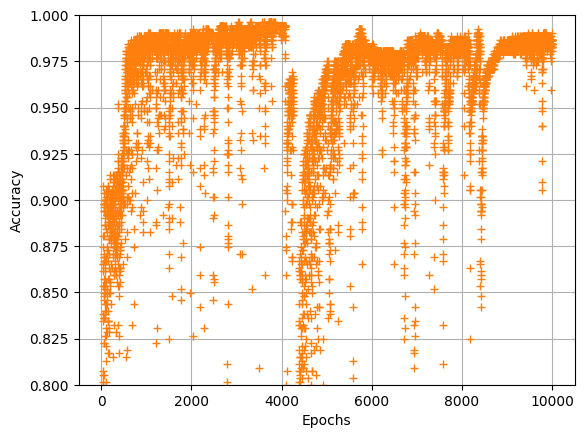

In [12]:
# acc = history.history['accuracy']
val_acc = np.array(history)[:,2]
epochs = range(1, len(val_acc) + 1)

# plt.plot(epochs, acc, 'b+')
plt.plot(epochs, val_acc, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.8,1))
plt.grid()
plt.show()

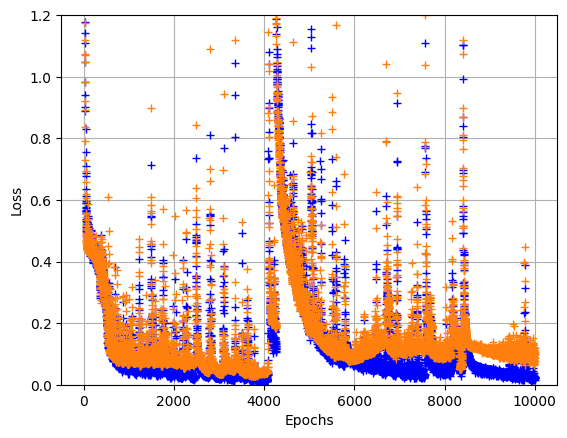

In [13]:
loss_values = np.array(history)[:,0]
val_loss_values = np.array(history)[:,1]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b+')
plt.plot(epochs, val_loss_values, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim((0.,1.2))
plt.grid()
plt.show()

In [14]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [15]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [16]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9852
Explained variance score: 0.9852
Mean squared error: 0.0027
Accuracy Score: 0.9960
Precision: [0.9944 0.9865 1.0000]
Recall: [0.9958 0.9955 0.9962]
Precision macro: 0.9936404020527311
Recall macro: 0.9958301208377517


### Train quality

In [17]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[707.,   3.,   0.],
       [  1., 220.,   0.],
       [  3.,   0., 795.]])

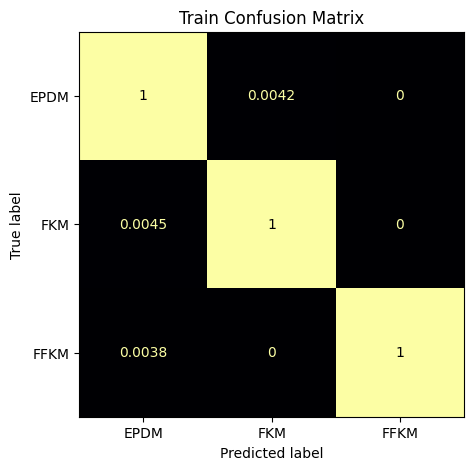

In [18]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

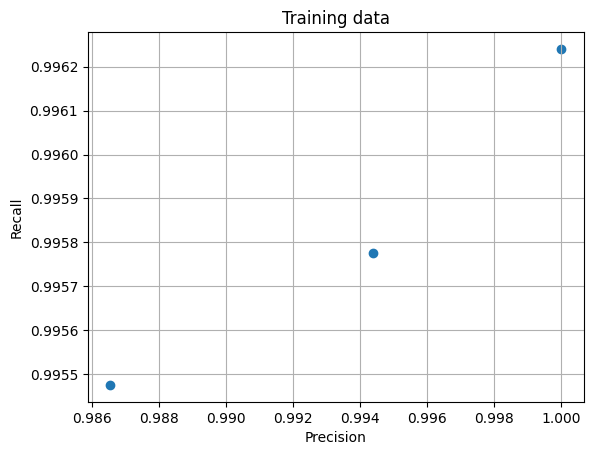

In [19]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [20]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[9.9975914e-01, 4.5650736e-06, 2.3631222e-04],
       [9.2234737e-01, 9.5080845e-03, 6.8144500e-02],
       [1.4728778e-04, 6.1816361e-05, 9.9979097e-01],
       ...,
       [3.6942656e-05, 1.3788779e-05, 9.9994922e-01],
       [5.5467524e-07, 9.9999940e-01, 4.2261781e-09],
       [3.6969715e-05, 1.5951160e-05, 9.9994707e-01]], dtype=float32)

### Test metrics

In [21]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [22]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9852
Explained variance score: 0.9852
Mean squared error: 0.0027
Accuracy Score: 0.9977
Precision: [1.0000 0.9783 1.0000]
Recall: [1.0000 1.0000 0.9952]
Precision macro: 0.9927536231884058
Recall macro: 0.9984051036682615


### Test quality

In [23]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[179.,   0.,   0.],
       [  0.,  45.,   0.],
       [  0.,   1., 208.]])

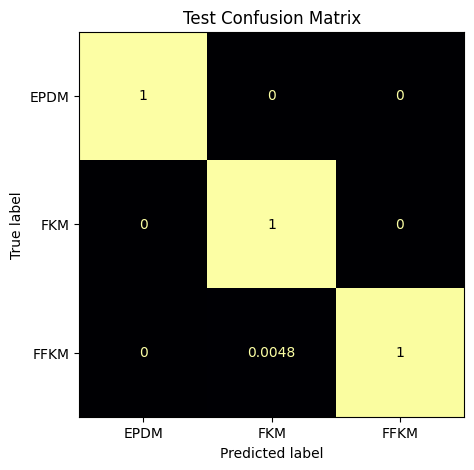

In [24]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

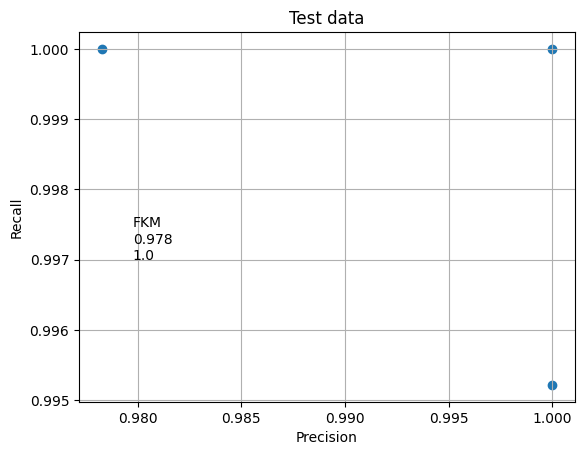

In [25]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [27]:
# torch.save(deepcopy(model.state_dict()), 'LSTMModel.pt')